<a href="https://colab.research.google.com/github/ylperdomo/Calculo-Numerico/blob/Atividade-1/Atividade1_Vers%C3%A3oFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Atividade 1 - Cálculo Numérico**
**Aluna**: Yasmin Leão Perdomo\
**RA**: 165878

#Preparação do ambiente

In [1]:
#Importa as bibliotecas necessárias
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image
#Define o visual do código
plt.style.use("seaborn-v0_8-whitegrid")
#Confirma que a preparação foi concluída
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


## Funções reutilizáveis

In [5]:
#Define uma função para truncar um número em uma quantidade escolhida de casas decimais
def truncar(numero, casas):
    #Calcula o fator que desloca a vírgula decimal
    fator = 10 ** casas
    #Trunca o número deslocado e recoloca a vírgula na posição original
    return math.trunc(numero * fator) / fator

#Define uma função para calcular erro absoluto, relativo e percentual
def calcular_erros(referencia, aproximacao):
    #Calcula a diferença absoluta entre referência e aproximação
    erro_abs = abs(referencia - aproximacao)
    #Evita divisão por zero quando a referência é nula
    if referencia == 0:
        #Define erros relativo e percentual como indefinidos
        return erro_abs, np.nan, np.nan
    #Calcula o erro relativo dividindo o erro absoluto pelo módulo da referência
    erro_rel = erro_abs / abs(referencia)
    #Converte o erro relativo para porcentagem e devolve os três erros
    return erro_abs, erro_rel, 100 * erro_rel

#Define a relação de Hagen-Poiseuille para a vazão volumétrica
def vazao(r, L, mu, dp):
    #Calcula e devolve Q em metros cúbicos por segundo
    return np.pi * r**4 * dp / (8 * mu * L)

# Parte A — Truncamento e arredondamento

Valores de referência:

- $x_1=3{,}14159265$
- $x_2=98{,}76543$
- $x_3=0{,}00498765$

Para cada valor, serão avaliadas de 0 a 4 casas decimais, usando truncamento e arredondamento.

In [6]:
#Armazena os três valores de referência em um dicionário
valores_A = {"x1": 3.14159265, "x2": 98.76543, "x3": 0.00498765}
#Cria uma lista vazia que receberá cada resultado calculado
resultados_A = []
#Percorre cada nome e cada valor de referência
for nome, referencia in valores_A.items():
    #Percorre as quantidades de casas decimais de 0 até 4
    for n in range(5):
        #Calcula a aproximação por arredondamento
        arredondado = round(referencia, n)
        #Calcula a aproximação por truncamento
        truncado = truncar(referencia, n)
        #Percorre as duas aproximações para evitar repetir o cálculo dos erros
        for metodo, aproximacao in [("Arredondamento", arredondado), ("Truncamento", truncado)]:
            #Calcula os três erros da aproximação atual
            ea, er, ep = calcular_erros(referencia, aproximacao)
            #Adiciona os resultados atuais à lista
            resultados_A.append([nome, referencia, n, metodo, aproximacao, ea, er, ep])
#Transforma a lista de resultados em uma tabela
tabela_A = pd.DataFrame(resultados_A, columns=["Valor", "Referência", "n", "Método", "Aproximação", "Ea", "Er", "E%"])
#Exibe a tabela completa
display(tabela_A)

,Valor,Referência,n,Método,Aproximação,Ea,Er,E%
0,x1,3.141593,0,Arredondamento,3.0000,0.141593,4.507034e-02,4.507034
1,x1,3.141593,0,Truncamento,3.0000,0.141593,4.507034e-02,4.507034
2,x1,3.141593,1,Arredondamento,3.1000,0.041593,1.323935e-02,1.323935
3,x1,3.141593,1,Truncamento,3.1000,0.041593,1.323935e-02,1.323935
4,x1,3.141593,2,Arredondamento,3.1400,0.001593,5.069562e-04,0.050696
5,x1,3.141593,2,Truncamento,3.1400,0.001593,5.069562e-04,0.050696
6,x1,3.141593,3,Arredondamento,3.1420,0.000407,1.296635e-04,0.012966
7,x1,3.141593,3,Truncamento,3.1410,0.000593,1.886464e-04,0.018865
8,x1,3.141593,4,Arredondamento,3.1416,0.000007,2.339578e-06,0.000234
9,x1,3.141593,4,Truncamento,3.1415,0.000093,2.949141e-05,0.002949


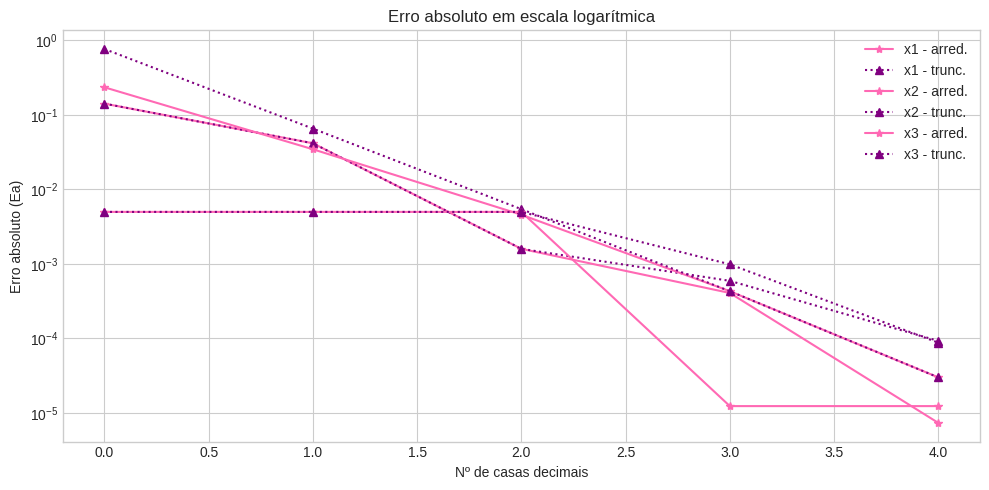

In [68]:
#Cria uma figura para comparar os erros absolutos
plt.figure(figsize=(10, 5))
#Percorre os três valores de referência
for nome in valores_A:
    #Seleciona somente as linhas do valor e do arredondamento atuais
    dados_arred = tabela_A[(tabela_A["Valor"] == nome) & (tabela_A["Método"] == "Arredondamento")]
    #Seleciona somente as linhas do valor e do truncamento atuais
    dados_trunc = tabela_A[(tabela_A["Valor"] == nome) & (tabela_A["Método"] == "Truncamento")]
    #Plota o erro absoluto do arredondamento em função de n
    plt.semilogy(dados_arred["n"], dados_arred["Ea"], marker="*", color= "#FF69B4", label=f"{nome} - arred.")
    #Plota o erro absoluto do truncamento em função de n
    plt.semilogy(dados_trunc["n"], dados_trunc["Ea"], marker="^", linestyle=":", color = "purple", label=f"{nome} - trunc.")
#Identifica o eixo horizontal
plt.xlabel("Nº de casas decimais")
#Identifica o eixo vertical
plt.ylabel("Erro absoluto (Ea)")
#Adiciona um título ao gráfico
plt.title("Erro absoluto em escala logarítmica")
#Mostra a legenda das seis curvas
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura.
plt.show()

Sim, o arredondamento sempre gera erro absoluto menor ou igual ao truncamento, pois o arredondamento escolhe o valor mais próximo do número original, enquanto o truncamento apenas elimina as casas seguintes.
Exemplo: para $x_1$com 3 casas decimais, o erro do arredondamento foi 0,000407, enquanto o do truncamento foi 0,000593.

# Parte B — Medidas de pressão arterial

As dez medidas, em mmHg, são:

`121,7; 120,4; 122,1; 119,8; 121,2; 120,9; 122,4; 121,0; 120,2; 121,5`.


In [22]:
#Cria um vetor com as dez medições originais
pressao = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
#Arredonda cada medição para o inteiro mais próximo
pressao_arred = np.round(pressao)
#Trunca cada medição para um número inteiro
pressao_trunc = np.trunc(pressao)
#Calcula a média de referência
media_ref = np.mean(pressao)
#Agrupa as três séries
series_B = {"Original": pressao, "Arredondada": pressao_arred, "Truncada": pressao_trunc}
#Cria uma lista vazia para armazenar as estatísticas
estatisticas_B = []
#Percorre cada série de pressão
for nome, dados in series_B.items():
    #Calcula média, mínimo, máximo, amplitude e desvio-padrão amostral
    estatisticas_B.append([nome, np.mean(dados), np.min(dados), np.max(dados), np.ptp(dados), np.std(dados, ddof=1)])
#Transforma as estatísticas em uma tabela
tabela_B = pd.DataFrame(estatisticas_B, columns=["Série", "Média", "Mínimo", "Máximo", "Amplitude", "Dp"])
#Exibe a tabela
display(tabela_B)

,Série,Média,Mínimo,Máximo,Amplitude,Dp
0,Original,121.12,119.8,122.4,2.6,0.833733
1,Arredondada,121.10,120.0,122.0,2.0,0.875595
2,Truncada,120.70,119.0,122.0,3.0,0.948683


In [21]:
#Cria uma lista vazia para os erros das médias aproximadas
erros_medias_B = []
#Percorre somente as duas séries aproximadas
for nome, dados in {"Arredondada": pressao_arred, "Truncada": pressao_trunc}.items():
    #Calcula a média da série aproximada
    media_aprox = np.mean(dados)
    #Calcula os três erros em relação a média de referência
    ea, er, ep = calcular_erros(media_ref, media_aprox)
    #Adiciona os resultados à lista
    erros_medias_B.append([nome, media_aprox, ea, er, ep])
#Transforma os erros das médias em uma tabela
erros_B = pd.DataFrame(erros_medias_B, columns=["Série", "Média aproximada", "Ea", "Er", "E%"])
#Exibe a tabela de erros
display(erros_B)

,Série,Média aproximada,Ea,Er,E%
0,Arredondada,121.1,0.02,0.000165,0.016513
1,Truncada,120.7,0.42,0.003468,0.346764


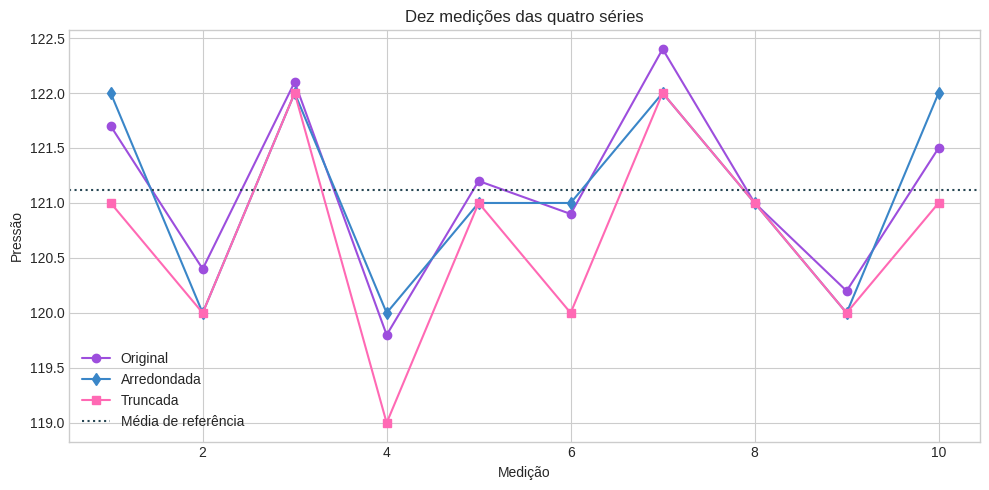

In [69]:
#Cria um vetor com os números das medições
medicoes = np.arange(1, len(pressao) + 1)
#Cria uma figura
plt.figure(figsize=(10, 5))
#Plota os dados originais
plt.plot(medicoes, pressao,color = "#9D4EDD", marker="o", label="Original")
#Plota os dados arredondados
plt.plot(medicoes, pressao_arred, color = "#3A86C8", marker="d", label="Arredondada")
#Plota os dados truncados
plt.plot(medicoes, pressao_trunc, color= "#FF69B4", marker="s", label="Truncada")
#Plota a média de referência
plt.axhline(media_ref, linestyle=":", color = "#264653", label="Média de referência")
#Identifica o eixo horizontal
plt.xlabel("Medição")
#Identifica o eixo vertical
plt.ylabel("Pressão")
#Adiciona um título ao gráfico
plt.title("Dez medições das quatro séries")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

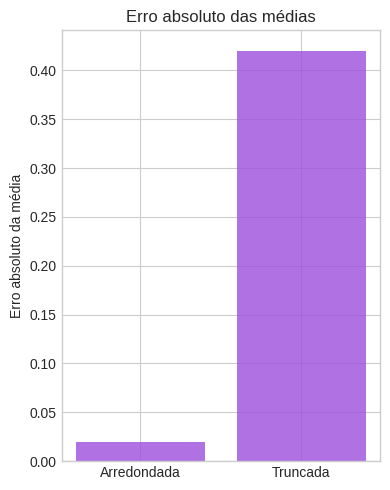

In [55]:
#Cria uma figura para o erro absoluto das médias
plt.figure(figsize=(4, 5))
#Desenha as barras usando os valores de Ea da tabela
plt.bar(erros_B["Série"], erros_B["Ea"], color = "#9D4EDD", alpha = 0.8)
#Identifica o eixo vertical com a unidade correta
plt.ylabel("Erro absoluto da média")
#Adiciona um título ao gráfico
plt.title("Erro absoluto das médias")
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

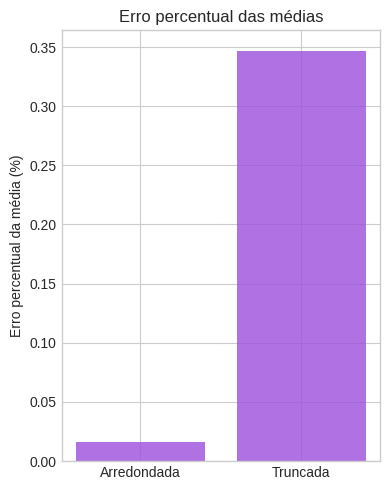

In [56]:
#Cria uma figura para o erro percentual das médias
plt.figure(figsize=(4, 5))
#Desenha as barras usando os valores de erro percentual
plt.bar(erros_B["Série"], erros_B["E%"], color ="#9D4EDD", alpha = 0.8)
#Identifica o eixo vertical em porcentagem
plt.ylabel("Erro percentual da média (%)")
#Adiciona um título ao gráfico.
plt.title("Erro percentual das médias")
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura.
plt.show()

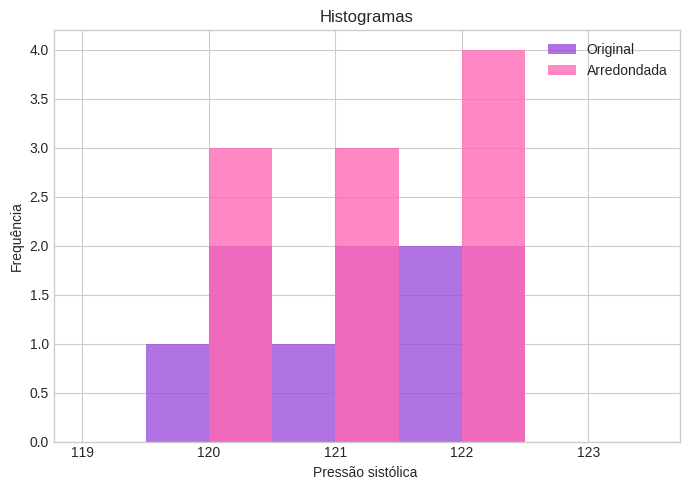

In [63]:
#Define intervalos comuns para comparar os dois histogramas
bins_B = np.arange(119, 124, 0.5)
#Cria uma figura para os histogramas
plt.figure(figsize=(7, 5))
#Desenha o histograma dos dados originais
plt.hist(pressao, bins=bins_B, alpha=0.8, color = "#9D4EDD", label="Original")
#Desenha o histograma dos dados arredondados
plt.hist(pressao_arred, bins=bins_B, alpha=0.8, color = "#FF69B4", label="Arredondada")
#Identifica o eixo horizontal
plt.xlabel("Pressão sistólica")
#Identifica o eixo vertical
plt.ylabel("Frequência")
#Adiciona um título ao gráfico
plt.title("Histogramas")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

A representação inteira preserva aproximadamente a média, mas altera a variabilidade dos dados. Na amostra original, a média é 121,12. Com arredondamento, fica 121,10, ou seja, muda muito pouco. Porém, o desvio-padrão passa de 0,834 para 0,876, e a amplitude muda de 2,6 para 2,0. Portanto, usar números inteiros pode ser suficiente para manter a média próxima da original, mas não preserva exatamente a dispersão dos valores.

# Parte C — Vazão em um tubo de pequeno diâmetro

Usaremos a relação de Hagen–Poiseuille:

$$Q=\frac{\pi r^4\Delta p}{8\mu L}$$

com:

- $r=0{,}80\,\text{mm}$
- $L=0{,}20\,\text{m}$
- $\mu=3{,}5\times10^{-3}\,\text{Pa s}$
- $\Delta p=1200\,\text{Pa}$


In [72]:
#Armazena o raio original em milímetros
r_mm = 0.80
#Converte o raio de milímetros para metros
r = r_mm * 1e-3
#Armazena o comprimento
L = 0.20
#Armazena a viscosidade dinâmica
mu = 3.5e-3
#Armazena a diferença de pressão
dp = 1200.0
#Calcula a vazão de referência
Q_ref_C = vazao(r, L, mu, dp)
#Exibe a vazão de referência
print(f"Vazão de referência = {Q_ref_C:.10e} m³/s")

Vazão de referência = 2.7574207520e-07 m^3/s


In [74]:
#Calcula o raio arredondado e converte para metros
r_arred = round(r_mm, 1) * 1e-3
#Calcula o raio truncado e converte para metros
r_trunc = truncar(r_mm, 1) * 1e-3
#Arredonda a viscosidade
mu_arred = round(mu, 3)
#Trunca a viscosidade
mu_trunc = truncar(mu, 3)
#Arredonda a pressão
dp_arred = round(dp, -2)
#Trunca a pressão
dp_trunc = truncar(dp, -2)
#Monta os cenários com os valores aproximados correspondentes
cenarios_C = {"Referência": (r, mu, dp), "r arredondado": (r_arred, mu, dp), "r truncado": (r_trunc, mu, dp), "mu arredondada": (r, mu_arred, dp), "mu truncada": (r, mu_trunc, dp), "dp arredondada": (r, mu, dp_arred), "dp truncada": (r, mu, dp_trunc), "Tudo arredondado": (r_arred, mu_arred, dp_arred), "Tudo truncado": (r_trunc, mu_trunc, dp_trunc)}
#Cria uma lista vazia para armazenar os resultados dos cenários
resultados_C = []
#Percorre cada cenário e suas três variáveis
for nome, (r_c, mu_c, dp_c) in cenarios_C.items():
    #Calcula a vazão do cenário atual
    Q_c = vazao(r_c, L, mu_c, dp_c)
    #Calcula os três erros em relação à vazão de referência
    ea, er, ep = calcular_erros(Q_ref_C, Q_c)
    #Adiciona os valores atuais à lista de resultados
    resultados_C.append([nome, r_c * 1e3, mu_c, dp_c, Q_c, ea, er, ep])
#Transforma os resultados em uma tabela
tabela_C = pd.DataFrame(resultados_C, columns=["Cenário", "r", "mu", "Delta", "Q", "Ea de Q", "Er de Q", "E% de Q"])
#Exibe a tabela de cenários
display(tabela_C)

,Cenário,r,mu,Delta,Q,Ea de Q,Er de Q,E% de Q
0,Referência,0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
1,r arredondado,0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
2,r truncado,0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
3,mu arredondada,0.8,0.0040,1200.0,2.412743e-07,3.446776e-08,0.125000,12.500000
4,mu truncada,0.8,0.0030,1200.0,3.216991e-07,4.595701e-08,0.166667,16.666667
5,dp arredondada,0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
6,dp truncada,0.8,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
7,Tudo arredondado,0.8,0.0040,1200.0,2.412743e-07,3.446776e-08,0.125000,12.500000
8,Tudo truncado,0.8,0.0030,1200.0,3.216991e-07,4.595701e-08,0.166667,16.666667


In [75]:
#Cria 101 valores de raio entre 0,70 e 0,90 mm
raios_mm_C = np.linspace(0.70, 0.90, 101)
#Converte todos os raios para metros
raios_m_C = raios_mm_C * 1e-3
#Arredonda os raios para uma casa decimal em milímetros
raios_arred_mm_C = np.round(raios_mm_C, 1)
#Trunca os raios para uma casa decimal em milímetros
raios_trunc_mm_C = np.trunc(raios_mm_C * 10) / 10
#Calcula Q para cada raio original
Q_original_C = vazao(raios_m_C, L, mu, dp)
#Calcula Q após arredondar cada raio
Q_arred_C = vazao(raios_arred_mm_C * 1e-3, L, mu, dp)
#Calcula Q após truncar cada raio
Q_trunc_C = vazao(raios_trunc_mm_C * 1e-3, L, mu, dp)
#Calcula o erro absoluto da vazão arredondada
Ea_arred_C = np.abs(Q_original_C - Q_arred_C)
#Calcula o erro absoluto da vazão truncada
Ea_trunc_C = np.abs(Q_original_C - Q_trunc_C)
#Calcula o erro relativo da vazão arredondada
Er_arred_C = Ea_arred_C / np.abs(Q_original_C)
#Calcula o erro relativo da vazão truncada
Er_trunc_C = Ea_trunc_C / np.abs(Q_original_C)
#Converte os erros relativos do arredondamento em porcentagem
Ep_arred_C = 100 * Er_arred_C
#Converte os erros relativos do truncamento em porcentagem
Ep_trunc_C = 100 * Er_trunc_C

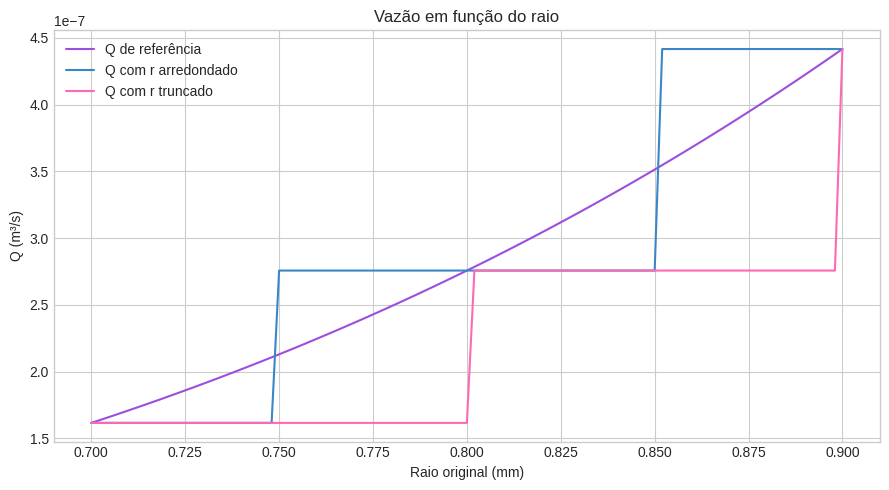

In [79]:
#Cria a figura de Q em função do raio
plt.figure(figsize=(9, 5))
#Plota a vazão calculada com o raio original
plt.plot(raios_mm_C, Q_original_C, label="Q de referência", color = "#9D4EDD")
#Plota a vazão após arredondar o raio
plt.plot(raios_mm_C, Q_arred_C, label="Q com r arredondado", color ="#3A86C8")
#Plota a vazão após truncar o raio
plt.plot(raios_mm_C, Q_trunc_C, label="Q com r truncado", color="#FF69B4")
#Identifica o eixo horizontal
plt.xlabel("Raio original (mm)")
#Identifica o eixo vertical.
plt.ylabel("Q (m³/s)")
#Adiciona um título ao gráfico
plt.title("Vazão em função do raio")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

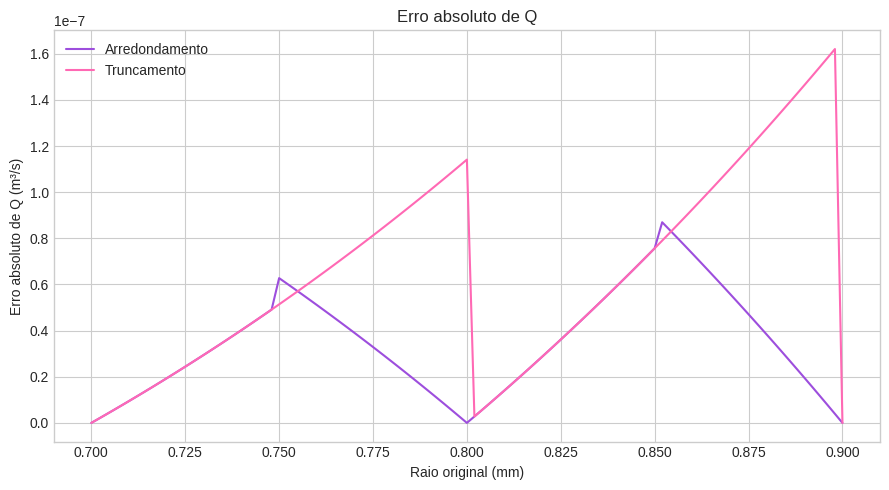

In [81]:
#Cria a figura do erro absoluto de Q
plt.figure(figsize=(9, 5))
#Plota o erro absoluto devido ao arredondamento do raio
plt.plot(raios_mm_C, Ea_arred_C, label="Arredondamento", color = "#9D4EDD")
#Plota o erro absoluto devido ao truncamento do raio
plt.plot(raios_mm_C, Ea_trunc_C, label="Truncamento", color="#FF69B4")
#Identifica o eixo horizontal
plt.xlabel("Raio original (mm)")
#Identifica o eixo vertical
plt.ylabel("Erro absoluto de Q (m³/s)")
#Adiciona um título ao gráfico
plt.title("Erro absoluto de Q")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

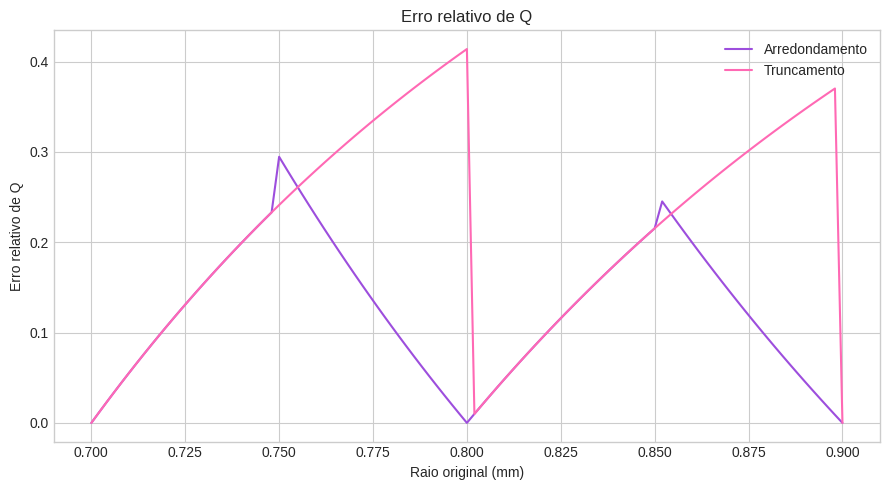

In [82]:
#Cria a figura do erro relativo de Q
plt.figure(figsize=(9, 5))
#Plota o erro relativo devido ao arredondamento do raio
plt.plot(raios_mm_C, Er_arred_C, label="Arredondamento", color = "#9D4EDD")
#Plota o erro relativo devido ao truncamento do raio
plt.plot(raios_mm_C, Er_trunc_C, label="Truncamento", color="#FF69B4")
#Identifica o eixo horizontal
plt.xlabel("Raio original (mm)")
#Identifica o eixo vertical
plt.ylabel("Erro relativo de Q")
#Adiciona um título ao gráfico
plt.title("Erro relativo de Q")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

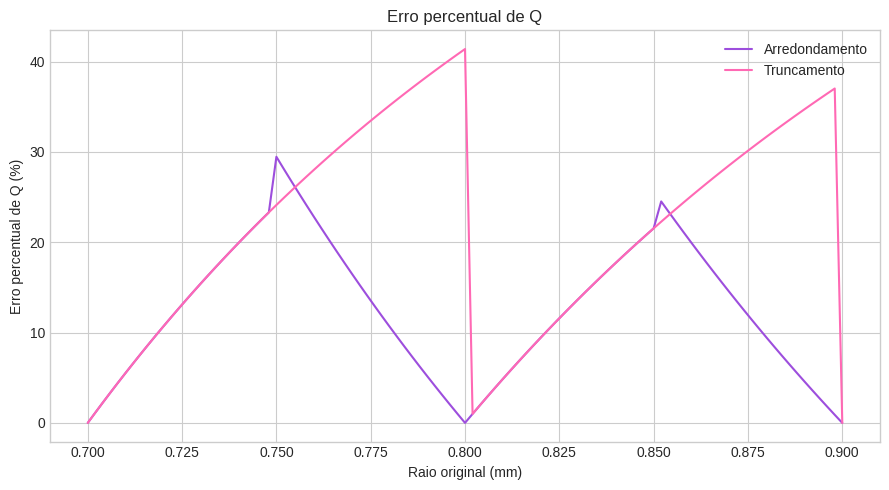

In [83]:
#Cria a figura do erro percentual de Q
plt.figure(figsize=(9, 5))
#Plota o erro percentual devido ao arredondamento do raio
plt.plot(raios_mm_C, Ep_arred_C, label="Arredondamento", color = "#9D4EDD")
#Plota o erro percentual devido ao truncamento do raio
plt.plot(raios_mm_C, Ep_trunc_C, label="Truncamento", color="#FF69B4")
#Identifica o eixo horizontal
plt.xlabel("Raio original (mm)")
#Identifica o eixo vertical
plt.ylabel("Erro percentual de Q (%)")
#Adiciona um título ao gráfico
plt.title("Erro percentual de Q")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

O erro no raio é amplificado porque a vazão depende do raio elevado à quarta potência $r^4$. Assim, uma pequena alteração no raio provoca uma alteração bem maior na vazão.
Por exemplo, um erro de aproximadamente 1% no raio pode gerar cerca de 4% de erro na vazão.

# Parte D — Escoamento em um nanocateter

Modelo didático:

- $r=50$ nm
- $L=10$ µm
- $\mu=3{,}5\times10^{-3}$ Pa s
- $\Delta p=5000$ Pa

In [84]:
#Converte o raio de 50 nm para metros
r_D = 50e-9
#Converte o comprimento de 10 micrômetros para metros
L_D = 10e-6
#Armazena a viscosidade
mu_D = 3.5e-3
#Armazena a diferença de pressão
dp_D = 5000.0
#Calcula a vazão de referência do nanocateter
Q_ref_D = vazao(r_D, L_D, mu_D, dp_D)
#Exibe a vazão de referência
print(f"Q(50 nm) = {Q_ref_D:.10e} m³/s")

Q(50 nm) = 3.5062418009e-19 m³/s


In [85]:
#Cria as variações de raio de 0,1 até 5,0 nm
delta_r_nm = np.arange(0.1, 5.0 + 0.1, 0.1)
#Converte as variações de raio para metros
delta_r_m = delta_r_nm * 1e-9
#Calcula os raios inferiores r menos delta r
r_menos = r_D - delta_r_m
#Calcula os raios superiores r mais delta r
r_mais = r_D + delta_r_m
#Calcula as vazões correspondentes aos raios inferiores
Q_menos = vazao(r_menos, L_D, mu_D, dp_D)
#Calcula as vazões correspondentes aos raios superiores
Q_mais = vazao(r_mais, L_D, mu_D, dp_D)
#Calcula o maior erro absoluto entre Q(r-) e Q(r+)
Ea_max_D = np.maximum(np.abs(Q_menos - Q_ref_D), np.abs(Q_mais - Q_ref_D))
#Calcula o maior erro relativo dividindo pelo módulo da vazão de referência
Er_max_D = Ea_max_D / abs(Q_ref_D)
#Converte o maior erro relativo em porcentagem
Ep_max_D = 100 * Er_max_D
#Calcula o erro relativo direto para o aumento de raio r+
erro_direto_D = (Q_mais - Q_ref_D) / Q_ref_D
#Calcula a aproximação linear 4 vezes delta r dividido por r
erro_linear_D = 4 * delta_r_m / r_D
#Monta uma tabela com todos os resultados
tabela_D1 = pd.DataFrame({"Delta r": delta_r_nm, "Q(r-)": Q_menos, "Q(r)": Q_ref_D, "Q(r+)": Q_mais, "Ea máximo": Ea_max_D, "Er máximo": Er_max_D, "E% máximo": Ep_max_D, "Erro direto r+": erro_direto_D, "Aprox. linear": erro_linear_D})
#Exibe a tabela
display(tabela_D1)

,Delta r,Q(r-),Q(r),Q(r+),Ea máximo,Er máximo,E% máximo,Erro direto r+,Aprox. linear
0,0.1,3.478276e-19,3.506242e-19,3.534376e-19,2.813420e-21,0.008024,0.802403,0.008024,0.008
1,0.2,3.450478e-19,3.506242e-19,3.562679e-19,5.643737e-21,0.016096,1.609626,0.016096,0.016
2,0.3,3.422846e-19,3.506242e-19,3.591152e-19,8.491019e-21,0.024217,2.421687,0.024217,0.024
3,0.4,3.395381e-19,3.506242e-19,3.619795e-19,1.135533e-20,0.032386,3.238605,0.032386,0.032
4,0.5,3.368082e-19,3.506242e-19,3.648609e-19,1.423675e-20,0.040604,4.060401,0.040604,0.040
5,0.6,3.340947e-19,3.506242e-19,3.677595e-19,1.713533e-20,0.048871,4.887093,0.048871,0.048
6,0.7,3.313977e-19,3.506242e-19,3.706753e-19,2.005115e-20,0.057187,5.718701,0.057187,0.056
7,0.8,3.287171e-19,3.506242e-19,3.736085e-19,2.298427e-20,0.065552,6.555245,0.065552,0.064
8,0.9,3.260527e-19,3.506242e-19,3.765590e-19,2.593477e-20,0.073967,7.396743,0.073967,0.072
9,1.0,3.234046e-19,3.506242e-19,3.795269e-19,2.890271e-20,0.082432,8.243216,0.082432,0.080


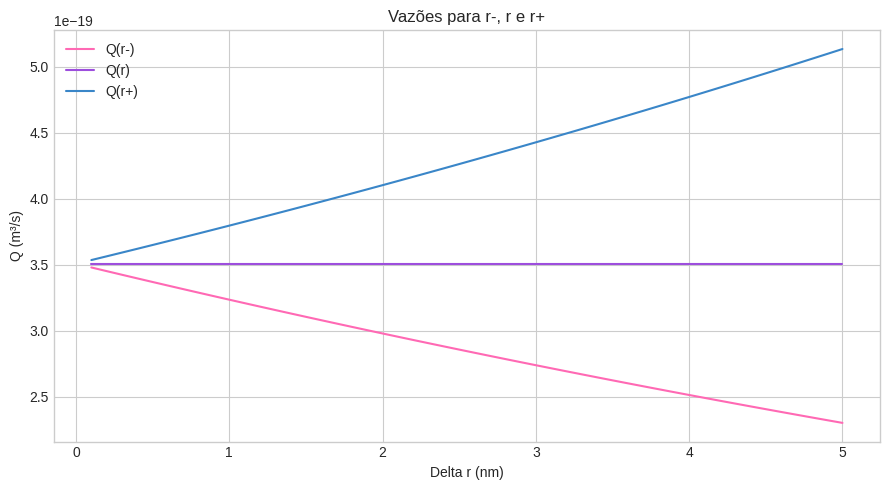

In [86]:
#Cria a figura das três vazões em função de delta r
plt.figure(figsize=(9, 5))
#Plota Q calculado com r menos delta r
plt.plot(delta_r_nm, Q_menos, label="Q(r-)", color = "#FF69B4")
#Plota Q de referência
plt.plot(delta_r_nm, np.full_like(delta_r_nm, Q_ref_D), label="Q(r)", color = "#9D4EDD")
#Plota Q calculado com r mais delta r
plt.plot(delta_r_nm, Q_mais, label="Q(r+)", color= "#3A86C8")
#Identifica o eixo horizontal
plt.xlabel("Delta r (nm)")
#Identifica o eixo vertical
plt.ylabel("Q (m³/s)")
#Adiciona um título ao gráfico
plt.title("Vazões para r-, r e r+")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

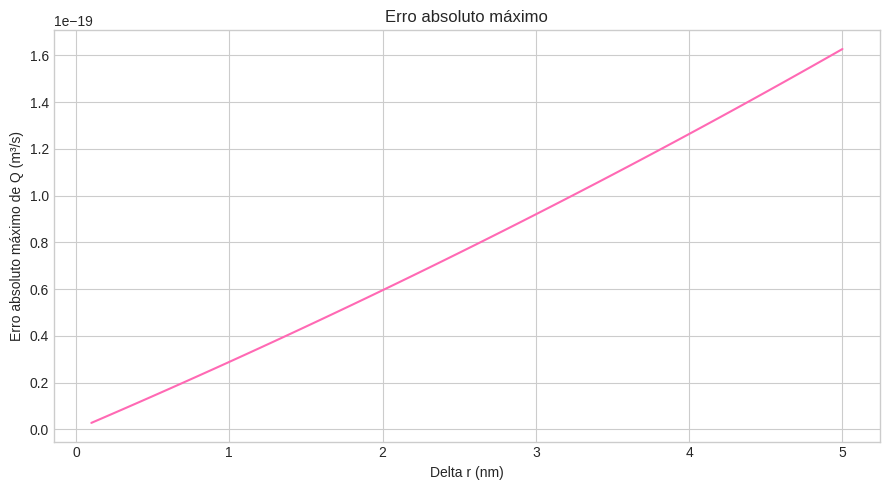

In [87]:
#Cria a figura do erro absoluto máximo
plt.figure(figsize=(9, 5))
#Plota o erro absoluto máximo em função de delta r
plt.plot(delta_r_nm, Ea_max_D, color = "#FF69B4")
#Identifica o eixo horizontal
plt.xlabel("Delta r (nm)")
#Identifica o eixo vertical
plt.ylabel("Erro absoluto máximo de Q (m³/s)")
#Adiciona um título ao gráfico
plt.title("Erro absoluto máximo")
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

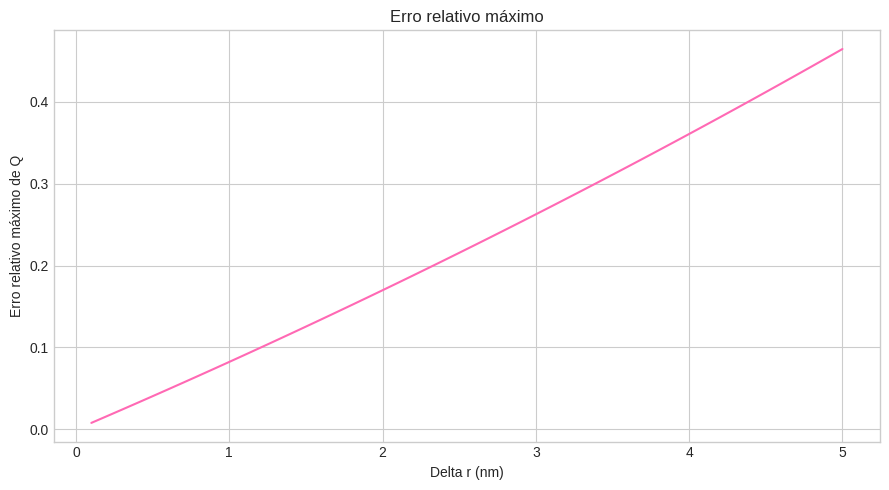

In [88]:
#Cria a figura do erro relativo máximo
plt.figure(figsize=(9, 5))
#Plota o erro relativo máximo em função de delta r
plt.plot(delta_r_nm, Er_max_D, color = "#FF69B4")
#Identifica o eixo horizontal
plt.xlabel("Delta r (nm)")
#Identifica o eixo vertical
plt.ylabel("Erro relativo máximo de Q")
#Adiciona um título ao gráfico
plt.title("Erro relativo máximo")
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

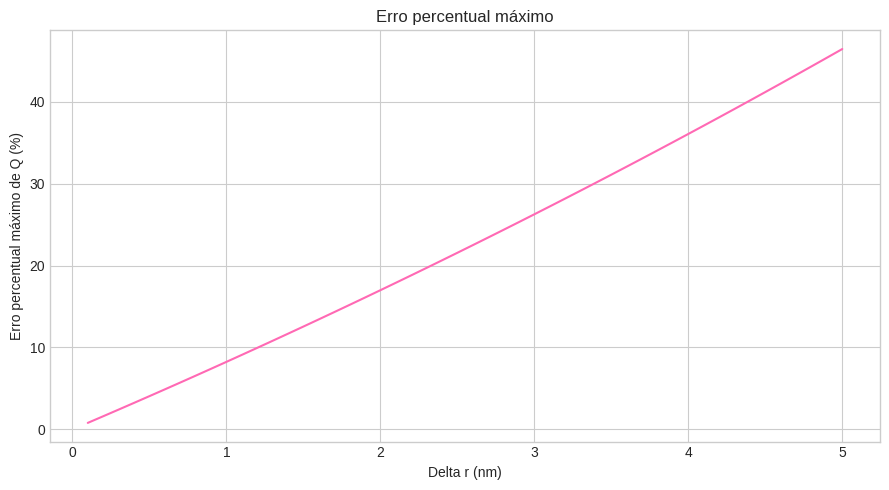

In [90]:
#Cria a figura do erro percentual máximo
plt.figure(figsize=(9, 5))
#Plota o erro percentual máximo em função de delta r
plt.plot(delta_r_nm, Ep_max_D, color = "#FF69B4")
#Identifica o eixo horizontal
plt.xlabel("Delta r (nm)")
#Identifica o eixo vertical
plt.ylabel("Erro percentual máximo de Q (%)")
#Adiciona um título ao gráfico
plt.title("Erro percentual máximo")
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

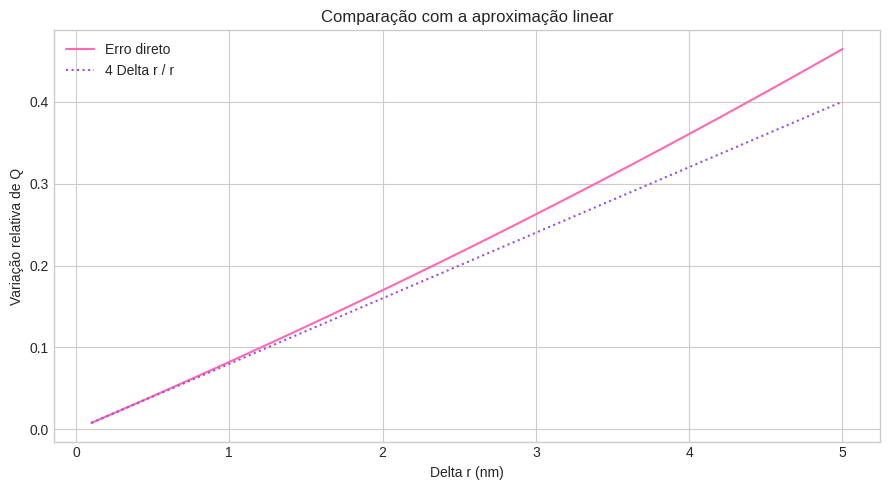

In [96]:
#Cria uma figura para comparar o erro direto e a aproximação linear
plt.figure(figsize=(9, 5))
#Plota o erro relativo calculado diretamente para r mais delta r
plt.plot(delta_r_nm, erro_direto_D, label="Erro direto", color = "#FF69B4")
#Plota a aproximação linear p
plt.plot(delta_r_nm, erro_linear_D, linestyle=":", label="4 Delta r / r", color = "#9D4EDD")
#Identifica o eixo horizontal
plt.xlabel("Delta r (nm)")
#Identifica o eixo vertical
plt.ylabel("Variação relativa de Q")
#Adiciona um título ao gráfico
plt.title("Comparação com a aproximação linear")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

In [92]:
#Define uma função que calcula r à quarta e Q em uma precisão escolhida
def calcular_com_tipo(tipo):
    #Converte o raio para o tipo numérico escolhido
    r_t = tipo(50e-9)
    #Converte o comprimento para o tipo numérico escolhido
    L_t = tipo(10e-6)
    #Converte a viscosidade para o tipo numérico escolhido
    mu_t = tipo(3.5e-3)
    #Converte a diferença de pressão para o tipo numérico escolhido
    dp_t = tipo(5000.0)
    #Converte pi para o tipo numérico escolhido
    pi_t = tipo(np.pi)
    #Calcula r à quarta potência no tipo escolhido
    r4_t = tipo(r_t ** tipo(4))
    #Calcula Q usando somente valores do tipo escolhido
    Q_t = tipo(pi_t * r4_t * dp_t / (tipo(8) * mu_t * L_t))
    #Devolve r à quarta e a vazão calculada
    return r4_t, Q_t

#Calcula r à quarta e Q usando float32
r4_32, Q_32 = calcular_com_tipo(np.float32)
#Calcula r à quarta e Q usando float64
r4_64, Q_64 = calcular_com_tipo(np.float64)
#Calcula a diferença absoluta entre as vazões das duas precisões
dif_abs_float = abs(float(Q_64) - float(Q_32))
#Calcula a diferença relativa usando float64 como referência
dif_rel_float = dif_abs_float / abs(float(Q_64))
#Obtém o epsilon de máquina do float32
eps_32 = np.finfo(np.float32).eps
#Obtém o epsilon de máquina do float64
eps_64 = np.finfo(np.float64).eps
#Organiza os resultados principais em uma tabela
tabela_float = pd.DataFrame({"Precisão": ["float32", "float64"], "r^4": [r4_32, r4_64], "Q": [Q_32, Q_64], "eps": [eps_32, eps_64]})
#Exibe a tabela de precisão
display(tabela_float)
#Exibe a diferença absoluta entre as vazões
print(f"Diferença absoluta em Q = {dif_abs_float:.10e}")
#Exibe a diferença relativa entre as vazões
print(f"Diferença relativa em Q = {dif_rel_float:.10e}")

,Precisão,r^4,Q,eps
0,float32,6.250000e-30,3.506242e-19,1.192093e-07
1,float64,6.250000e-30,3.506242e-19,2.220446e-16


Diferença absoluta em Q = 5.2286276892e-26
Diferença relativa em Q = 1.4912342006e-07


In [93]:
#Cria razões delta r dividido por r progressivamente menores, de 10^-2 a 10^-16
fracoes = np.logspace(-2, -16, 15)
#Calcula delta1 pela diferença entre duas vazões próximas
delta1 = np.array([(vazao(r_D * (1 + f), L_D, mu_D, dp_D) - Q_ref_D) / Q_ref_D for f in fracoes])
#Calcula delta2 pela expressão algébrica
delta2 = (1 + fracoes) ** 4 - 1
#Calcula a mesma variação de forma mais estável para servir como referência numérica
delta_estavel = np.expm1(4 * np.log1p(fracoes))
#Calcula o erro absoluto numérico de delta1 em relação à forma estável
erro_delta1 = np.abs(delta1 - delta_estavel)
#Calcula o erro absoluto numérico de delta2 em relação à forma estável
erro_delta2 = np.abs(delta2 - delta_estavel)
#Organiza a comparação em uma tabela
tabela_cancelamento = pd.DataFrame({"Delta r / r": fracoes, "delta1": delta1, "delta2": delta2, "Referência estável": delta_estavel, "Erro numérico delta1": erro_delta1, "Erro numérico delta2": erro_delta2})
#Exibe a tabela de cancelamento numérico
display(tabela_cancelamento)

,Delta r / r,delta1,delta2,Referência estável,Erro numérico delta1,Erro numérico delta2
0,1.000000e-02,4.060401e-02,4.060401e-02,4.060401e-02,3.400058e-16,2.081668e-17
1,1.000000e-03,4.006004e-03,4.006004e-03,4.006004e-03,2.905662e-16,5.143455e-16
2,1.000000e-04,4.000600e-04,4.000600e-04,4.000600e-04,1.660456e-16,1.530893e-16
3,1.000000e-05,4.000060e-05,4.000060e-05,4.000060e-05,1.926831e-16,3.084826e-16
4,1.000000e-06,4.000006e-06,4.000006e-06,4.000006e-06,5.319214e-16,2.437524e-16
5,1.000000e-07,4.000001e-07,4.000001e-07,4.000001e-07,2.735939e-16,1.855862e-16
6,1.000000e-08,4.000000e-08,4.000000e-08,4.000000e-08,4.088052e-16,1.769650e-16
7,1.000000e-09,4.000000e-09,4.000000e-09,4.000000e-09,2.328339e-16,3.249615e-16
8,1.000000e-10,4.000000e-10,4.000000e-10,4.000000e-10,3.755555e-17,3.303615e-17
9,1.000000e-11,3.999984e-11,4.000000e-11,4.000000e-11,1.610249e-16,3.309015e-18


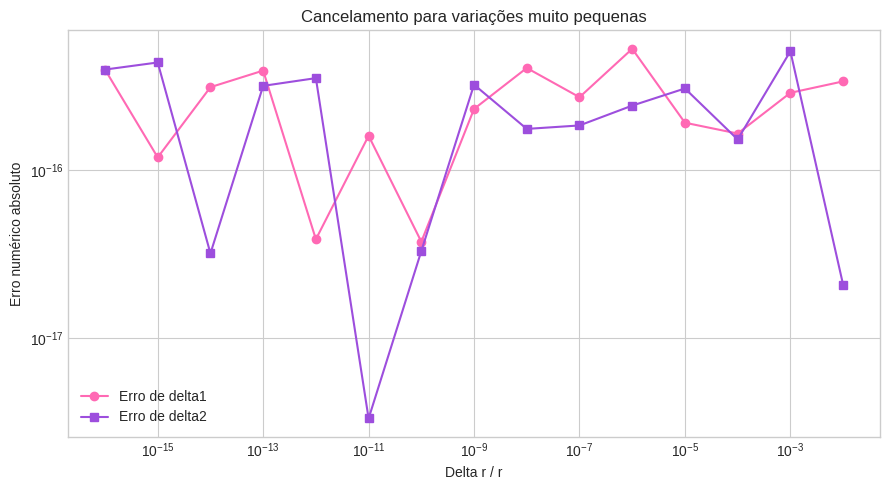

In [97]:
#Evita valores exatamente nulos no eixo logarítmico substituindo-os pelo menor float64 positivo normal
erro_delta1_plot = np.maximum(erro_delta1, np.finfo(np.float64).tiny)
#Faz a mesma proteção para os erros numéricos de delta2
erro_delta2_plot = np.maximum(erro_delta2, np.finfo(np.float64).tiny)
#Cria a figura para visualizar a perda de significânci
plt.figure(figsize=(9, 5))
#Plota o erro numérico de delta1 em escala log-log
plt.loglog(fracoes, erro_delta1_plot, marker="o", label="Erro de delta1", color = "#FF69B4")
#Plota o erro numérico de delta2 em escala log-log
plt.loglog(fracoes, erro_delta2_plot, marker="s", label="Erro de delta2", color = "#9D4EDD")
#Identifica o eixo horizontal
plt.xlabel("Delta r / r")
#Identifica o eixo vertical
plt.ylabel("Erro numérico absoluto")
#Adiciona um título ao gráfico
plt.title("Cancelamento para variações muito pequenas")
#Mostra a legenda
plt.legend()
#Ajusta automaticamente os espaços da figura
plt.tight_layout()
#Exibe a figura
plt.show()

Os resultados mostram que, conforme $\frac{\Delta r}{r}$ diminui, as duas expressões ficam muito próximas. Porém, para valores muito pequenos, a primeira começa a perder precisão por cancelamento numérico, pois subtrai duas vazões quase iguais.

Ao reduzir a escala, a superfície se torna maior em relação ao volume, fazendo com que o fluido tenha proporcionalmente mais contato com as paredes. Por isso, em estruturas muito pequenas, como o nanocateter, os efeitos viscosos e de parede se tornam mais importantes no escoamento.

# Parte E — Síntese visual em PNG

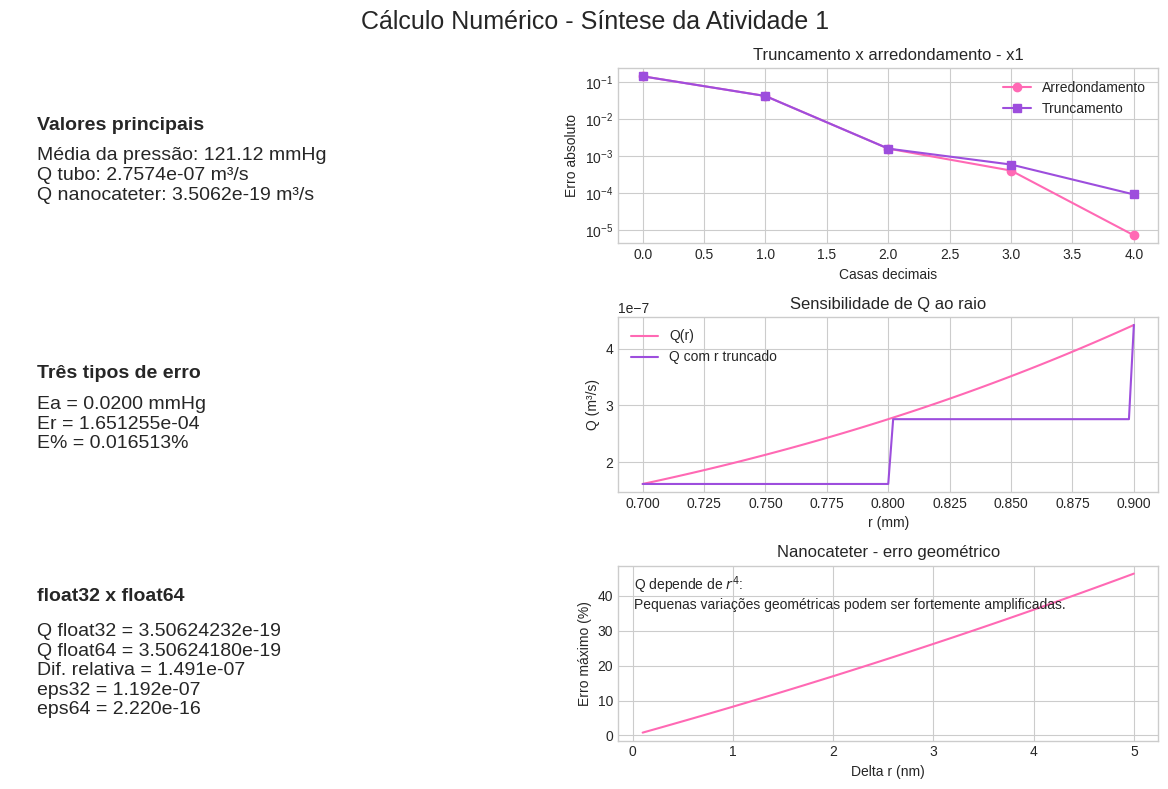

Arquivo salvo: quadro_resultados.png


In [125]:
#Cria uma figura
fig, axs = plt.subplots(3, 2, figsize=(12, 8), dpi=100)
#Define um título geral para o quadro de resultados
fig.suptitle("Cálculo Numérico - Síntese da Atividade 1", fontsize=18)
#Seleciona o primeiro painel para os valores principais
ax = axs[0, 0]
#Desliga os eixos do painel de texto
ax.axis("off")
#Monta o texto com os principais valores de pressão e vazão
texto_principal = f"Média da pressão: {media_ref:.2f} mmHg\nQ tubo: {Q_ref_C:.4e} m³/s\nQ nanocateter: {Q_ref_D:.4e} m³/s"
#Escreve os valores principais no painel
ax.text(0.05,0.65, "Valores principais", fontsize=14, fontweight="bold", transform=ax.transAxes)
#Escreve os números abaixo do título do painel
ax.text(0.05, 0.25, texto_principal, fontsize=14, transform=ax.transAxes)
#Seleciona no painel seguinte somente os dados de x1 da Parte A
ax = axs[0, 1]
#Extrai os erros de arredondamento de x1
ea_a = tabela_A[(tabela_A["Valor"] == "x1") & (tabela_A["Método"] == "Arredondamento")]["Ea"].to_numpy()
#Extrai os erros de truncamento de x1
ea_t = tabela_A[(tabela_A["Valor"] == "x1") & (tabela_A["Método"] == "Truncamento")]["Ea"].to_numpy()
#Plota os erros de arredondamento
ax.semilogy(range(5), ea_a, marker="o", label="Arredondamento", color = "#FF69B4")
#Plota os erros de truncamento
ax.semilogy(range(5), ea_t, marker="s", label="Truncamento", color = "#9D4EDD")
#Define o título do painel
ax.set_title("Truncamento x arredondamento - x1")
#Identifica o eixo horizontal
ax.set_xlabel("Casas decimais")
#Identifica o eixo vertical
ax.set_ylabel("Erro absoluto")
#Mostra a legenda do painel
ax.legend()
#Seleciona o terceiro painel para mostrar os três tipos de erro
ax = axs[1, 0]
#Desliga os eixos do painel de texto
ax.axis("off")
#Seleciona a linha correspondente à série arredondada da pressão
linha_erro_B = erros_B[erros_B["Série"] == "Arredondada"].iloc[0]
#Monta o texto com Ea, Er e E% da média arredondada
texto_erros = f"Ea = {linha_erro_B['Ea']:.4f} mmHg\nEr = {linha_erro_B['Er']:.6e}\nE% = {linha_erro_B['E%']:.6f}%"
#Escreve o título do painel
ax.text(0.05, 0.65, "Três tipos de erro", fontsize=14, fontweight="bold", transform=ax.transAxes)
#Escreve os três erros no painel
ax.text(0.05, 0.25, texto_erros, fontsize=14, transform=ax.transAxes)
#Seleciona o quarto painel para a sensibilidade da vazão ao raio
ax = axs[1, 1]
#Plota Q de referência em função do raio
ax.plot(raios_mm_C, Q_original_C, label="Q(r)", color = "#FF69B4")
#Plota Q com raio truncado para evidenciar a sensibilidade
ax.plot(raios_mm_C, Q_trunc_C, label="Q com r truncado", color = "#9D4EDD")
#Define o título do painel
ax.set_title("Sensibilidade de Q ao raio")
#Identifica o eixo horizontal
ax.set_xlabel("r (mm)")
#Identifica o eixo vertical
ax.set_ylabel("Q (m³/s)")
#Mostra a legenda do painel
ax.legend()
#Seleciona o quinto painel para comparar float32 e float64
ax = axs[2, 0]
#Desliga os eixos do painel de texto
ax.axis("off")
#Monta o texto da comparação entre precisões
texto_float = f"Q float32 = {float(Q_32):.8e}\nQ float64 = {float(Q_64):.8e}\nDif. relativa = {dif_rel_float:.3e}\neps32 = {eps_32:.3e}\neps64 = {eps_64:.3e}"
#Escreve o título do painel
ax.text(0.05, 0.80, "float32 x float64", fontsize=14, fontweight="bold", transform=ax.transAxes)
#Escreve a comparação numérica no painel
ax.text(0.05, 0.15, texto_float, fontsize=14, transform=ax.transAxes)
#Seleciona o último painel para o nanocateter
ax = axs[2, 1]
#Plota o erro percentual máximo em função da variação geométrica
ax.plot(delta_r_nm, Ep_max_D, color = "#FF69B4")
#Define o título do painel
ax.set_title("Nanocateter - erro geométrico")
#Identifica o eixo horizontal
ax.set_xlabel("Delta r (nm)")
#Identifica o eixo vertical
ax.set_ylabel("Erro máximo (%)")
#Escreve uma conclusão curta dentro do painel
ax.text(0.03, 0.95, "Q depende de $r^4$:\nPequenas variações geométricas podem ser fortemente amplificadas.", transform=ax.transAxes, va="top", fontsize=10)
#Ajusta os espaços reservando área para o título geral
plt.tight_layout()
#Salva o quadro único em PNG com 1600 por 1000 pixels
plt.savefig("quadro_resultados.png", dpi=100)
#Exibe o quadro no notebook
plt.show()
#Confirma o nome do arquivo criado
print("Arquivo salvo: quadro_resultados.png")

# GIF demonstrativo

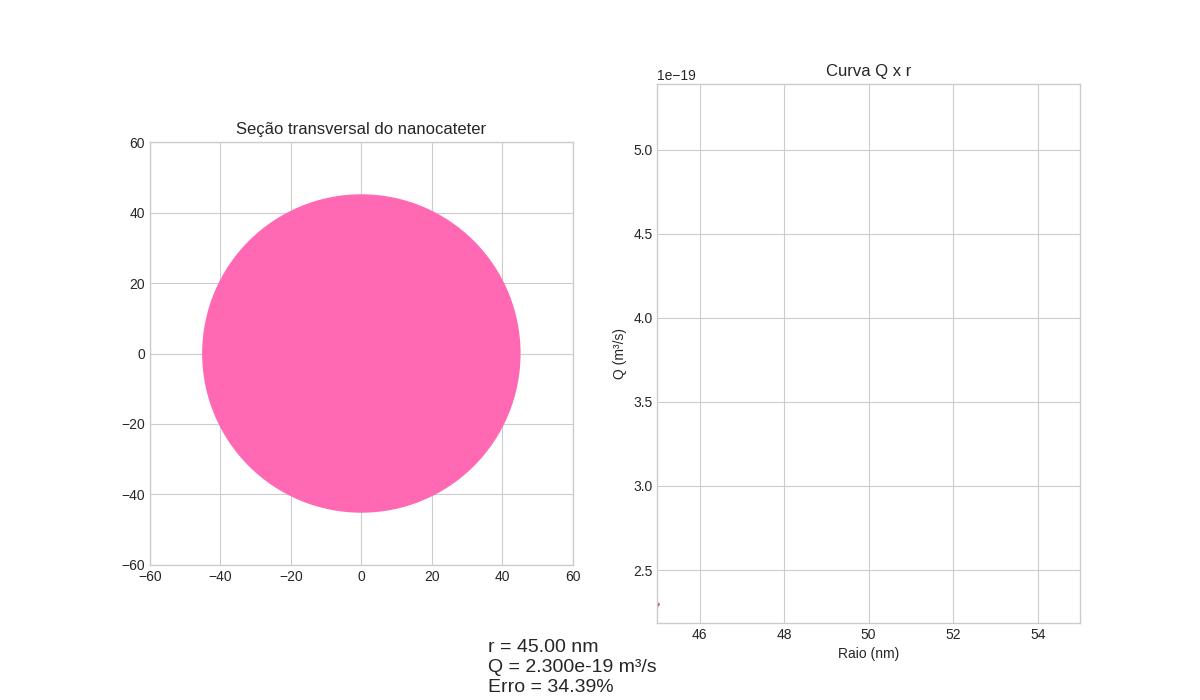

Arquivo salvo: nanocateter.gif


In [136]:
#Cria 40 valores de raio igualmente espaçados entre 45 e 55 nm
raios_gif_nm = np.linspace(45, 55, 40)
#Converte os raios do GIF para metros
raios_gif_m = raios_gif_nm * 1e-9
#Calcula a vazão correspondente a cada raio do GIF
Q_gif = vazao(raios_gif_m, L_D, mu_D, dp_D)
#Calcula o erro percentual de cada vazão em relação à vazão de 50 nm
erro_gif = 100 * np.abs(Q_gif - Q_ref_D) / abs(Q_ref_D)
#Cria uma figura com dois painéis para a animação
fig_gif, (ax_canal, ax_curva) = plt.subplots(1, 2, figsize=(12, 7))
#Reserva espaço na parte inferior da figura
fig.subplots_adjust(bottom=0.30)

#Define a função chamada a cada quadro da animação
def atualizar_gif(i):
    #Limpa o painel da seção transversal antes de desenhar o quadro atual
    ax_canal.clear()
    #Limpa o painel da curva antes de desenhar o quadro atual
    ax_curva.clear()
    #Seleciona o raio atual em nanômetros
    raio_atual = raios_gif_nm[i]
    #Cria um círculo cujo raio representa a seção transversal atual
    circulo = plt.Circle((0, 0), raio_atual,  color="#FF69B4", linewidth=1)
    #Adiciona o círculo ao primeiro painel
    ax_canal.add_patch(circulo)
    #Mantém a mesma escala espacial em todos os quadros
    ax_canal.set_xlim(-60, 60)
    #Mantém a mesma escala vertical em todos os quadros
    ax_canal.set_ylim(-60, 60)
    #Mantém a seção transversal sem deformação
    ax_canal.set_aspect("equal")
    #Define o título do painel da seção transversal
    ax_canal.set_title("Seção transversal do nanocateter")
    #Escreve o raio, a vazão e o erro percentual do quadro atual
    ax_canal.text(0.8, -0.3, f"r = {raio_atual:.2f} nm\nQ = {Q_gif[i]:.3e} m³/s\nErro = {erro_gif[i]:.2f}%", transform=ax_canal.transAxes, fontsize=14)
    #Desenha progressivamente a curva Q por r até o quadro atual
    ax_curva.plot(raios_gif_nm[:i + 1], Q_gif[:i + 1], marker="*", markersize=3, color = "#9D4EDD")
    #Mantém todo o intervalo de raios visível durante a animação
    ax_curva.set_xlim(45, 55)
    #Mantém uma escala vertical constante durante a animação
    ax_curva.set_ylim(Q_gif.min() * 0.95, Q_gif.max() * 1.05)
    #Identifica o eixo horizontal da curva
    ax_curva.set_xlabel("Raio (nm)")
    #Identifica o eixo vertical da curva
    ax_curva.set_ylabel("Q (m³/s)")
    #Define o título do painel da curva
    ax_curva.set_title("Curva Q x r")

#Cria a animação chamando a função de atualização para cada um dos 40 quadros
animacao = FuncAnimation(fig_gif, atualizar_gif, frames=len(raios_gif_nm), interval=125)
#Salva a animação em GIF usando 8 quadros por segundo
animacao.save("nanocateter.gif", writer=PillowWriter(fps=8))
#Fecha a figura estática para evitar uma saída duplicada no notebook
plt.close(fig_gif)

#Exibe o GIF final dentro do Colab
display(Image(filename="nanocateter.gif"))
#Confirma o nome do arquivo criado
print("Arquivo salvo: nanocateter.gif")